<div>
<div align="center" >
<img src="https://www.ufpr.br/portalufpr/wp-content/uploads/2015/11/ufpr_logo.jpg" />
</div>
<div align="center">

---

SEPT - Setor de Educação Profissional e Tecnológica - Especialização em Inteligência Artificial Aplicada

---

Prof. Dr. Jaime Wojciechowski (jaimewo@ufpr.br )

Aluno: Luis Gustavo de Matos dos Santos (gustavomatos@ufpr.br)

---

</div>
</div>



## Trabalho de Conclusão de Curso

## Detecção de Câner de Próstata em Imagens de Ressonância Magnética

Este trabalho apresenta um estudo sobre o uso de inteligência artificial (IA) para o diagnóstico de câncer de próstata, utilizando o conjunto de dados do Desafio [PI-CAI](https://pi-cai.grand-challenge.org/, "Artificial Intelligence & Radiologists at Prostate Cancer Detection in MRI") (Desafio Público de Treinamento e Desenvolvimento em IA para Câncer de Próstata).

###O Desafio PI-CAI
O Desafio PI-CAI foi lançado em 2022 com o objetivo de promover o desenvolvimento de algoritmos de IA para a detecção e o diagnóstico de câncer de próstata em imagens de ressonância magnética (RM). O desafio oferece um conjunto de dados público com 1500 exames de RM de 1476 pacientes, divididos em conjuntos de treino, validação e teste.

### O Conjunto de Dados
O conjunto de dados do Desafio PI-CAI inclui:
* Imagens de RM: T2 axial, ADC axial, b-valor alto axial, T2 sagital e T2 coronal.
* Anotações: Contornos de lesões prostáticas, com classificação PI-RADS e Gleason.

### Relevância do Estudo
O câncer de próstata é um dos tipos de câncer mais comuns em homens. O diagnóstico precoce é crucial para o sucesso do tratamento, mas a detecção pode ser desafiadora. A IA tem o potencial de melhorar a precisão e a eficiência do diagnóstico, além de auxiliar na segmentação de lesões e na avaliação do prognóstico.

### Objetivos do Estudo

Este estudo tem como objetivos:

* Avaliar o desempenho de diferentes modelos de IA para a detecção de câncer de próstata em imagens de RM.
* Investigar o uso de IA para a segmentação de lesões prostáticas.
* Analisar o potencial da IA para a avaliação do prognóstico do câncer de próstata.

### Metodologia

Para alcançar os objetivos do estudo, serão utilizados os seguintes métodos:

* Pré-processamento das imagens de RM.
* Treinamento e avaliação de diferentes modelos de IA para a detecção e segmentação de lesões prostáticas.
* Análise do desempenho dos modelos de IA.

# Configuração do Ambiente

Informações de sistema

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Fri Jun 21 03:33:57 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:00:04.0 Off |                    0 |
| N/A   38C    P0              47W / 400W |      2MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

Instalação de bibliotecas

In [ ]:
!pip install picai_baseline
!pip install monai
!pip install batchgenerators

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.8/907.8 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 MB 29.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.3 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.1 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-many

In [ ]:
%cd /content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline

/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline


In [ ]:
!pip install -e .

Obtaining file:///content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia%20Artificial%20Aplicada/TCC/picai_baseline
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for picai_baseline (pyproject.toml) ... done
  Created wheel for picai_baseline: filename=picai_baseline-0.8.4-0.editable-py3-none-any.whl size=10286 sha256=666888d681874025a57dd0b07cebb2049f50f7f3889218fd841f8cd9640017d4
  Stored in directory: /tmp/pip-ephem-wheel-cache-356zby7i/wheels/12/e3/6f/b675a8b073878d28c53dccafda9ad27f4b732fd6c327720ca4
Successfully built picai_baseline
  Attempting uninstall: picai_baseline
    Found existing installation: picai_baseline 0.8.5
    Uninstalling picai_baseline-0.8.5:
      Successfully uninstalled picai_baseline-0.8.5


Bibliotecas

In [ ]:
import os
import glob
import shutil
import sys
import time
import tempfile
import logging
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf

from sklearn.model_selection import train_test_split

#from picai_baseline.prepare_data_semi_supervised import prepare_data_semi_supervised

import torch
from torch.utils.tensorboard import SummaryWriter

import monai
from monai.transforms import EnsureType
from monai.config import print_config
from monai.networks.nets import UNet, VNet
from monai.networks.layers import Norm
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.optimizers import Novograd
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.handlers import (
    MeanDice,
    MLFlowHandler,
    StatsHandler,
    TensorBoardImageHandler,
    TensorBoardStatsHandler,
)
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
)

from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from scipy.ndimage import gaussian_filter

from batchgenerators.transforms.abstract_transforms import Compose
from batchgenerators.transforms.color_transforms import BrightnessMultiplicativeTransform, ContrastAugmentationTransform, BrightnessTransform
from batchgenerators.transforms.color_transforms import GammaTransform
from batchgenerators.transforms.noise_transforms import GaussianNoiseTransform, GaussianBlurTransform
from batchgenerators.transforms.resample_transforms import SimulateLowResolutionTransform
from batchgenerators.transforms.spatial_transforms import SpatialTransform, MirrorTransform
from batchgenerators.transforms.utility_transforms import NumpyToTensor

from monai.utils import first

import nibabel as nib
from ipywidgets import interact, interactive, IntSlider, ToggleButtons
from IPython.display import clear_output

print_config()

MONAI version: 1.3.1
Numpy version: 1.25.2
Pytorch version: 2.3.0+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 96bfda00c6bd290297f5e3514ea227c6be4d08b4
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 4.0.2
scikit-image version: 0.19.3
scipy version: 1.11.4
Pillow version: 9.4.0
Tensorboard version: 2.15.2
gdown version: 4.7.3
TorchVision version: 0.18.0+cu121
tqdm version: 4.66.4
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.0.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: 4.41.2
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
   

# Exploração inicial

In [ ]:
data_dir = '/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset'

Baseando-se nos dados da planilha fornecida, podemos observar várias características clínicas e patológicas de pacientes submetidos a exames de ressonância magnética (MRI) para avaliação de câncer de próstata. As variáveis incluem:

* **Idade do Paciente (patient_age)**: Um fator crucial em estudos epidemiológicos e de risco.
* **Níveis de PSA (psa)**: Um biomarcador importante para o rastreamento do câncer de próstata.
* **Densidade do PSA (psad)**: Um indicador potencialmente mais preciso do risco de câncer de próstata, ajustado pelo volume da próstata.
* **Volume da Próstata (prostate_volume)**: Informação relevante para diagnósticos e acompanhamento da doença.
* **Tipo de Histopatologia (histopath_type)**: Dados sobre o método de biópsia utilizado, o que pode influenciar o diagnóstico e a classificação do câncer.
* **Escala Gleason do Lesão (lesion_GS)**, **Escala ISUP do Lesão (lesion_ISUP)**, e * **Escala ISUP do Caso (case_ISUP)**: Métricas para a classificação da agressividade do câncer.
* **Presença de Câncer de Próstata Clinicamente Significativo (case_csPCa)**: Um indicador binário que sinaliza a necessidade de intervenção clínica.

In [ ]:
clinical_information_file = f'{data_dir}/input/picai_labels/clinical_information/marksheet.csv'
clinical_df = pd.read_csv(clinical_information_file)
clinical_df.head()

,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa
0,10000,1000000,2019-07-02,73,7.7,NaN,55.0,MRBx,0+0,0,0,NO
1,10001,1000001,2016-05-27,64,8.7,0.09,102.0,NaN,NaN,NaN,0,NO
2,10002,1000002,2021-04-18,58,4.2,0.06,74.0,NaN,NaN,NaN,0,NO
3,10003,1000003,2019-04-05,72,13.0,NaN,71.5,SysBx,0+0,0,0,NO
4,10004,1000004,2020-10-21,67,8.0,0.10,78.0,SysBx+MRBx,"0+0,0+0","0,0",0,NO


## Distribuição da Idade dos Pacientes
O histograma da idade dos pacientes mostra a distribuição das idades dentro da população estudada. Esse gráfico é fundamental para entender a demografia dos pacientes e pode revelar, por exemplo, se a maioria dos casos de câncer de próstata ocorre em uma faixa etária específica. Uma distribuição com pico em idades mais avançadas reforçaria a noção de que o risco de câncer de próstata aumenta com a idade.

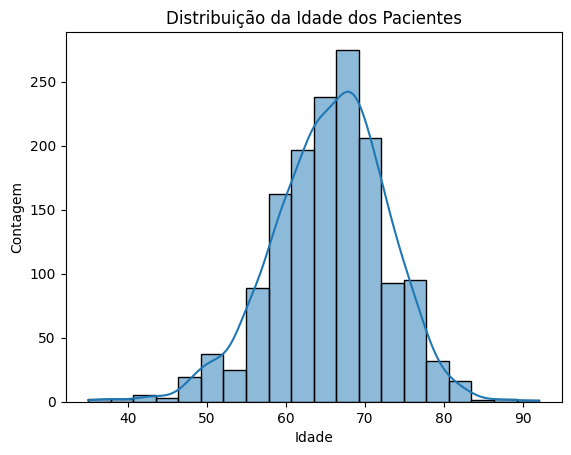

In [ ]:
sns.histplot(data=clinical_df, x="patient_age", bins=20, kde=True)
plt.title("Distribuição da Idade dos Pacientes")
plt.xlabel("Idade")
plt.ylabel("Contagem")
plt.show()

## Níveis de PSA por Faixa Etária

A dispersão dos níveis de PSA em relação à idade dos pacientes pode indicar se há uma tendência de aumento ou diminuição dos níveis de PSA à medida que os pacientes envelhecem. Uma possível descoberta pode ser a identificação de uma correlação positiva, sugerindo que níveis mais altos de PSA são mais comuns em faixas etárias mais velhas, o que poderia indicar um risco aumentado de desenvolvimento de câncer de próstata com a idade.

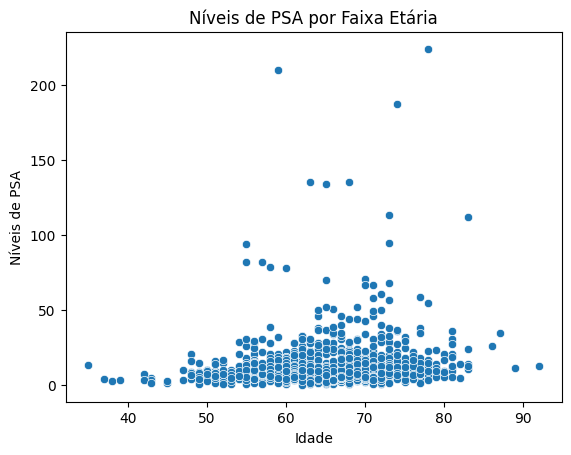

In [ ]:
sns.scatterplot(data=clinical_df, x="patient_age", y="psa")
plt.title("Níveis de PSA por Faixa Etária")
plt.xlabel("Idade")
plt.ylabel("Níveis de PSA")
plt.show()

## Volume da Próstata e Níveis de PSA

Este gráfico explora a relação entre o volume da próstata e os níveis de PSA, ajudando a identificar se pacientes com próstatas maiores tendem a ter níveis mais elevados de PSA. Uma correlação positiva entre essas duas variáveis poderia sugerir que um volume maior de próstata está associado a um maior risco de câncer, ou pode simplesmente refletir uma característica fisiológica natural do envelhecimento masculino.

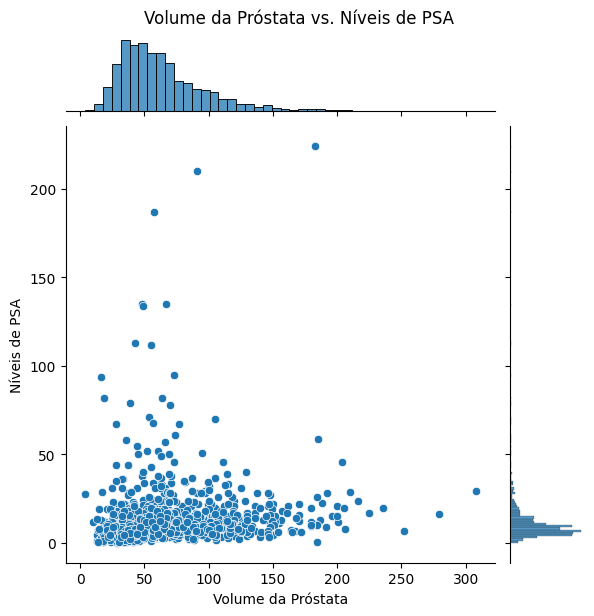

In [ ]:
sns.jointplot(data=clinical_df, x="prostate_volume", y="psa", kind="scatter")
plt.suptitle("Volume da Próstata vs. Níveis de PSA", y=1.02)
plt.xlabel("Volume da Próstata")
plt.ylabel("Níveis de PSA")
plt.show()

## Tipos de Biópsia e ISUP dos Casos

A distribuição dos tipos de biópsia em relação aos graus ISUP dos casos fornece insights sobre a eficácia e o uso de diferentes métodos de biópsia na determinação do grau de agressividade do câncer de próstata. Este gráfico pode revelar, por exemplo, se certos tipos de biópsia (como MRBx ou SysBx) estão mais frequentemente associados a casos com graus ISUP mais altos, sugerindo sua potencial maior precisão ou adequação para detectar cânceres mais agressivos.

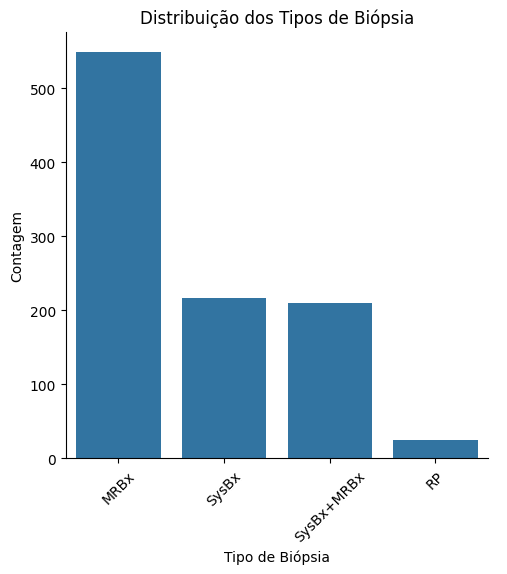

In [ ]:
sns.catplot(x="histopath_type", kind="count", data=clinical_df)
plt.title("Distribuição dos Tipos de Biópsia")
plt.xlabel("Tipo de Biópsia")
plt.ylabel("Contagem")
plt.xticks(rotation=45)
plt.show()

## Distribuição de Casos de Câncer Significativo (csPCa)

A contagem de casos de câncer de próstata clinicamente significativo (csPCa) versus não significativos fornece uma visão geral da prevalência de casos que requerem atenção clínica imediata dentro da amostra estudada. Este gráfico é útil para avaliar a carga de doença e pode ajudar na alocação de recursos de saúde para o tratamento e manejo do câncer de próstata.

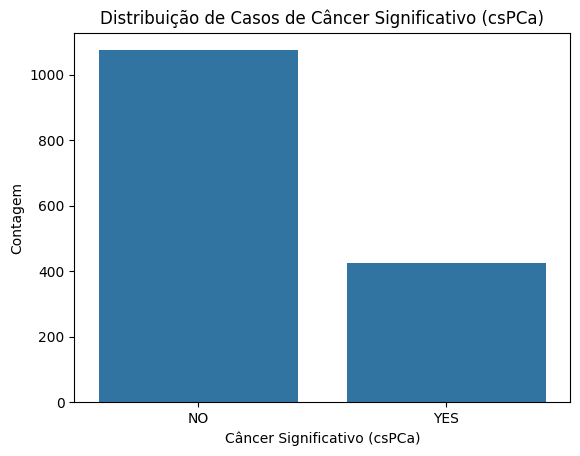

In [ ]:
sns.countplot(x="case_csPCa", data=clinical_df)
plt.title("Distribuição de Casos de Câncer Significativo (csPCa)")
plt.xlabel("Câncer Significativo (csPCa)")
plt.ylabel("Contagem")
plt.show()

## Relação entre PSA e PSAD

A relação entre os níveis de PSA e PSAD (densidade de PSA) é crucial para avaliar o risco de câncer de próstata. Um gráfico mostrando essa relação pode ajudar a identificar padrões ou limiares nos quais o risco de câncer aumenta significativamente, fornecendo uma ferramenta adicional para a triagem e diagnóstico precoce do câncer de próstata.

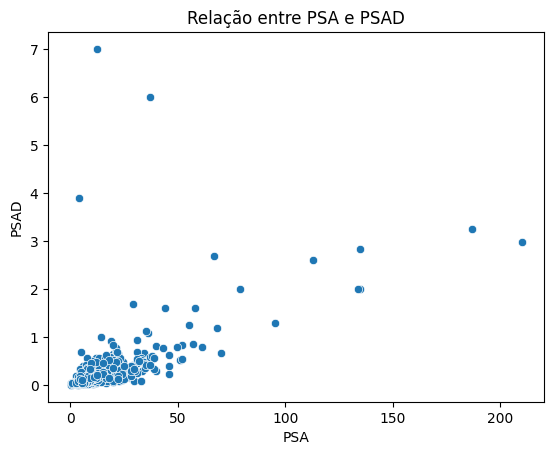

In [ ]:
sns.scatterplot(data=clinical_df, x="psa", y="psad")
plt.title("Relação entre PSA e PSAD")
plt.xlabel("PSA")
plt.ylabel("PSAD")
plt.show()

## Histograma de Volume da Próstata

O histograma do volume da próstata mostra a distribuição dos tamanhos da próstata na população estudada. Este gráfico pode ajudar a identificar se a maioria dos pacientes tem próstatas dentro de um intervalo de tamanho considerado normal ou se há uma prevalência significativa de próstatas aumentadas. Tamanhos de próstata anormalmente grandes podem ser um indicador de hiperplasia benigna ou outras condições que podem ou não estar relacionadas ao câncer de próstata.

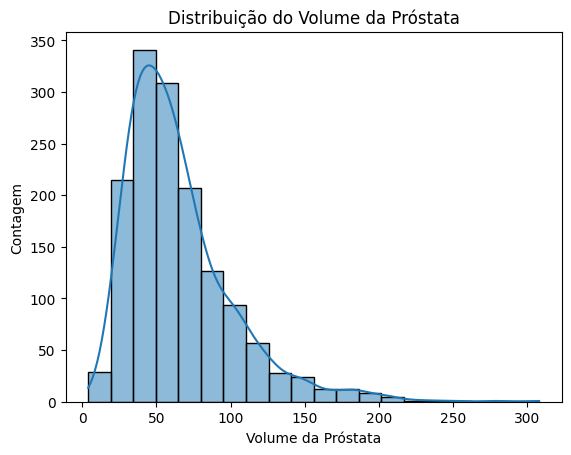

In [ ]:
sns.histplot(data=clinical_df, x="prostate_volume", bins=20, kde=True)
plt.title("Distribuição do Volume da Próstata")
plt.xlabel("Volume da Próstata")
plt.ylabel("Contagem")
plt.show()

## Correlação dos Dados Clínicos

A análise da matriz de correlação dos dados clínicos do conjunto de dados revela algumas relações interessantes e potencialmente significativas entre as variáveis. Notavelmente, observa-se uma correlação positiva moderada entre os níveis de PSA (Antígeno Prostático Específico) e a PSAD (Densidade do PSA), com um coeficiente de correlação de aproximadamente 0,60. Isso sugere que, conforme os níveis de PSA aumentam, a densidade do PSA tende a aumentar também, o que pode indicar uma maior probabilidade de presença de câncer de próstata.

Outra correlação positiva moderada é observada entre a idade do paciente e a ISUP do caso (uma escala que mede a agressividade do câncer de próstata), com um coeficiente de 0,20, indicando que pacientes mais velhos tendem a ter classificações ISUP mais altas, refletindo um potencial aumento na agressividade do câncer com a idade.

Interessantemente, há uma correlação negativa entre o volume da próstata e o ISUP do caso (-0,21), sugerindo que maiores volumes da próstata podem estar inversamente relacionados à agressividade do câncer diagnosticado. Essa relação inversa pode ser explorada mais a fundo para entender se o aumento no volume da próstata afeta de maneira benéfica a classificação da agressividade do câncer ou se reflete outros mecanismos biológicos ou de diagnóstico.

Estas correlações entre variáveis clínicas oferecem insights valiosos para a compreensão dos fatores que podem influenciar o diagnóstico e a progressão do câncer de próstata. Tais análises são cruciais para o desenvolvimento de modelos de diagnóstico e prognóstico mais precisos, permitindo abordagens personalizadas para o tratamento e manejo de pacientes com câncer de próstata.

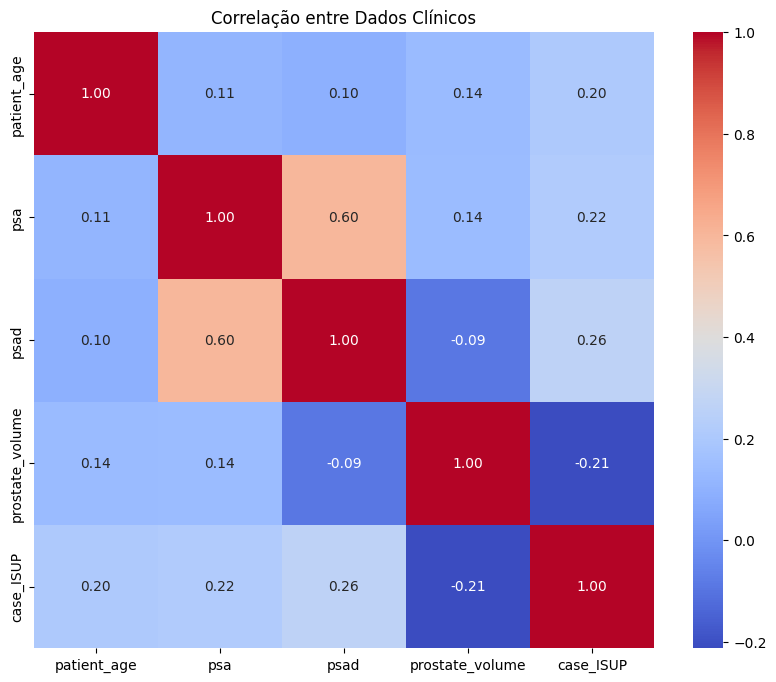

In [ ]:
columns_to_exclude = ['patient_id', 'study_id']

corr_df = clinical_df.select_dtypes(include=[np.number]).drop(columns=columns_to_exclude)

correlation_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre Dados Clínicos')
plt.show()


# Processamento de Imagens e Labels Médicas
O processo de preparação de conjuntos de dados médicos para análises computacionais ou treinamento de modelos de aprendizado de máquina envolve várias etapas cruciais para garantir que os dados estejam em um formato uniforme e otimizado. Estas etapas incluem o carregamento, processamento e salvamento das imagens e labels. Vamos detalhar cada uma dessas etapas:

## Carregamento dos Dados
O primeiro passo envolve o carregamento das imagens e labels do disco. Utilizamos a biblioteca SimpleITK, uma ferramenta poderosa e flexível para leitura e escrita de imagens médicas em uma variedade de formatos.

## Processamento das Imagens
Após o carregamento, as imagens passam por um processo de transformação que inclui:

* Reamostragem: Ajusta o espaçamento entre os pixels da imagem para um valor uniforme, assegurando a consistência das dimensões físicas (em mm) em todo o conjunto de dados.
* Normalização da Intensidade: Normaliza as intensidades dos pixels da imagem para um intervalo padrão (geralmente [0, 1]), melhorando a estabilidade e performance dos modelos de aprendizado de máquina.
* Redimensionamento: Altera o tamanho das imagens para dimensões específicas, necessário para algumas arquiteturas de redes neurais que requerem entradas de tamanho fixo.

## Binarização dos Labels
Os labels, ou anotações, que identificam as regiões de interesse nas imagens, muitas vezes precisam ser binarizados. Isso significa transformar qualquer valor de pixel maior que zero em 1, e o restante em 0, simplificando as anotações para segmentação binária.

## Salvamento dos Dados Processados
Finalmente, as imagens e labels processados são salvos em um formato padrão (geralmente NIfTI, denotado por .nii ou .nii.gz para a versão compactada), facilitando seu uso em aplicações subsequentes. Para imagens, esse processo inclui uma etapa de compressão para economizar espaço em disco.

## Geração do Arquivo dataset.json
Além do processamento de imagens e labels, é crucial gerar um arquivo dataset.json, que descreve o conjunto de dados processado, incluindo informações sobre modalidades, labels e metadados relevantes. Esse arquivo é fundamental para a utilização dos dados em frameworks de aprendizado de máquina como o nnUNet, facilitando a especificação de configurações de treinamento e validação.


In [ ]:
prepare_data_semi_supervised(
        workdir="/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir",
        inputdir="/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/input",
        spacing=[3.0, 0.5, 0.5],
        matrix_size=[20, 256, 256],
    )

Preparing annotations folder with human-expert and AI-derived annotations


100%|██████████| 1478/1478 [01:59<00:00, 12.35it/s] 


"
    Saved mha2nnunet_settings to /content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligência Artificial Aplicada/TCC/PICAI_Dataset/workdir/mha2nnunet_settings/Task2203_picai_baseline.json, with 1500 cases.
    
Saved updated mha2nnunet settings to /content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligência Artificial Aplicada/TCC/PICAI_Dataset/workdir/mha2nnunet_settings/Task2203_picai_baseline.json
Writing log to /content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligência Artificial Aplicada/TCC/PICAI_Dataset/workdir/nnUNet_raw_data/picai_prep_20240409211407.log


100%|██████████| 1500/1500 [4:54:01<00:00, 11.76s/it]

Saved cross-validation splits to /content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligência Artificial Aplicada/TCC/PICAI_Dataset/workdir/nnUNet_raw_data/Task2203_picai_baseline/splits.json


In [ ]:
!python "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/plan_overview.py" --task=Task2203_picai_baseline --workdir="/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir" --preprocessed_data_path="/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/nnUNet_raw_data/Task2203_picai_baseline" --overviews_path="/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews" --splits=picai_pub

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

Preparing fold 0 (train)..
Skipping 11475_1001499, case not found (likely because preprocessing failed)!
Preparing fold 0 (val)..
Preparing fold 1 (train)..
Skipping 11475_1001499, case not found (likely because preprocessing failed)!
Preparing fold 1 (val)..
Preparing fold 2 (train)..
Skipping 11475_1001499, case not found (likely because preprocessing failed)!
Preparing fold 2 (val)..
Preparing fold 3 (train)..
Skipping 11475_1001499, case not found (likely because preprocessing failed)!
Preparing fold 3 (val)..
Preparing fold 4 (train)..
Preparing fold 4 (val)..
Skipping 11475_1001499, case not found (likely because preprocessing failed)!
Finished.


Quando se trata de diagnóstico médico, como é o caso da identificação de câncer de próstata clinicamente significativo (csPCa), um modelo treinado em um conjunto de dados desbalanceado pode se tornar enviesado em favor da classe majoritária (neste caso, casos sem csPCa). Isso pode levar o modelo a apresentar uma alta precisão geral, simplesmente predizendo a maioria dos casos como negativos, mas falhando em identificar corretamente os casos positivos, que são críticos do ponto de vista clínico.

## Estratégia de Separação e Balanceamento dos Dados
Para mitigar os efeitos do desequilíbrio de classes no conjuntos de dados médicos, vamos adotar a estratégia de subamostragem (Undersampling) da classe majoritária, ou seja, reduzir o número de instâncias da classe mais representada para igualar o da classe minoritária.

In [ ]:
significant_cases = clinical_df[clinical_df['case_csPCa'] == 'YES']
non_significant_cases = clinical_df[clinical_df['case_csPCa'] == 'NO']

random_state = 37

subsampled_non_significant_cases = non_significant_cases.sample(n=len(significant_cases), random_state=random_state)

balanced_clinical_df = pd.concat([significant_cases, subsampled_non_significant_cases]).reset_index(drop=True)
balanced_clinical_df = balanced_clinical_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
print(balanced_clinical_df['case_csPCa'].value_counts())

case_csPCa
YES    425
NO     425
Name: count, dtype: int64


## Plot Inicial

Para entender a relação entre a imagem de ressonância magnética (MRI) de um paciente e o respectivo rótulo (label) que indica a presença de câncer de próstata clinicamente significativo (csPCa = 'YES'), é importante visualizar tanto a imagem quanto o rótulo de segmentação. No contexto de imagens médicas, como as de MRI, a segmentação é frequentemente usada para identificar regiões de interesse (ROIs), como lesões ou tumores.

In [ ]:
patient_id = balanced_clinical_df[balanced_clinical_df['case_csPCa'] == 'YES']['patient_id'].iloc[0]
study_id = balanced_clinical_df[balanced_clinical_df['case_csPCa'] == 'YES']['study_id'].iloc[0]

images_dir = f"{data_dir}/workdir/nnUNet_raw_data/Task2203_picai_baseline/imagesTr"
labels_dir = f"{data_dir}/workdir/nnUNet_raw_data/Task2203_picai_baseline/labelsTr"

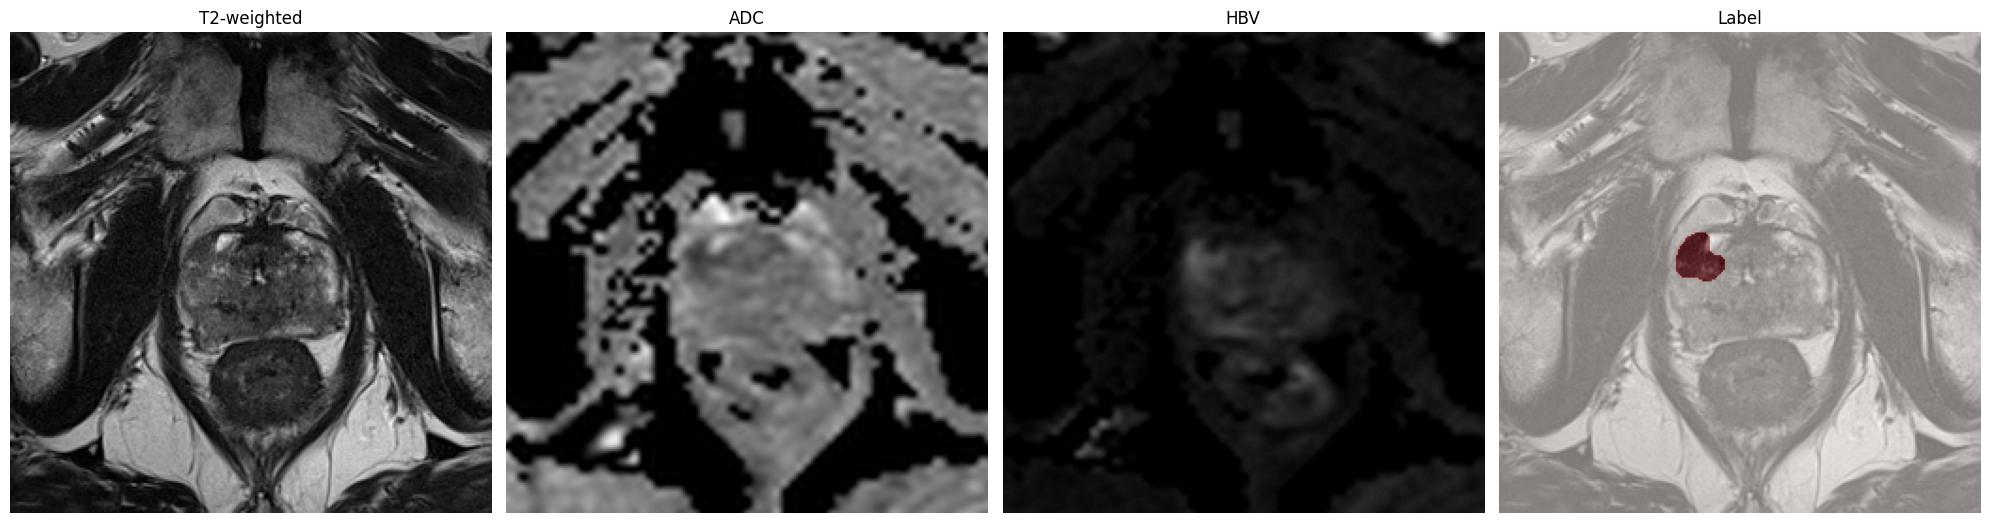

In [ ]:
def load_and_process_image(file_path):
    """Carrega uma imagem usando SimpleITK e retorna a fatia média do volume."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    img = sitk.ReadImage(file_path)
    img_array = sitk.GetArrayFromImage(img)
    middle_slice = img_array[len(img_array) // 2]
    return middle_slice

image_t2w_path = f"{images_dir}/{patient_id}_{study_id}_0000.nii.gz"
image_adc_path = f"{images_dir}/{patient_id}_{study_id}_0001.nii.gz"
image_hbv_path = f"{images_dir}/{patient_id}_{study_id}_0002.nii.gz"
label_path = f"{labels_dir}/{patient_id}_{study_id}.nii.gz"

img_t2w = load_and_process_image(image_t2w_path)
img_adc = load_and_process_image(image_adc_path)
img_hbv = load_and_process_image(image_hbv_path)
label_img = load_and_process_image(label_path)


fig, axes = plt.subplots(1, 4, figsize=(20, 8))
images = [img_t2w, img_adc, img_hbv, label_img]
titles = ["T2-weighted", "ADC", "HBV", "Label"]

for ax, img, title in zip(axes, images, titles):
    if title == "Label":
        ax.imshow(images[0], cmap='gray')
        ax.imshow(img, alpha=0.5, cmap='Reds')
        ax.set_title(title)
    else:
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

Vamos entender o que são as imagens T2-weighted (T2w), Apparent Diffusion Coefficient (ADC) e High B-Value (HBV) na ressonância magnética (MRI) e como elas contribuem para o diagnóstico de câncer de próstata.

1. Imagens T2-Weighted (T2w)

Descrição: As imagens T2-weighted são sequências de ressonância magnética que produzem imagens de alto contraste baseadas nas diferenças nos tempos de relaxamento T2 dos tecidos. Tecidos com tempos de relaxamento T2 longos, como líquidos e outros tecidos hidratados, aparecem brilhantes nessas imagens.
Influência no Diagnóstico de Câncer de Próstata: No caso do câncer de próstata, as imagens T2w são particularmente valiosas porque permitem uma excelente visualização da anatomia da próstata e da cápsula prostática. As áreas cancerosas geralmente aparecem como regiões hipointensas (mais escuras) na próstata hiperintensa (mais clara), facilitando a identificação e a localização do câncer.
2. Imagens de Apparent Diffusion Coefficient (ADC)

Descrição: Imagens ADC são derivadas de sequências de difusão ponderada (DWI). Elas medem o movimento aparente de moléculas de água nos tecidos. Em tecidos normais, onde as moléculas de água se movem relativamente livremente, o ADC é alto. Em tecidos densos ou com muitas células, como tumores, o movimento da água é mais restrito, resultando em um ADC mais baixo.
Influência no Diagnóstico de Câncer de Próstata: Imagens ADC são extremamente úteis para o diagnóstico de câncer de próstata porque as áreas de carcinoma tendem a mostrar um ADC baixo devido à alta densidade celular que restringe a difusão da água. Essas áreas aparecem mais escuras nas imagens ADC, o que ajuda a distinguir o tecido canceroso do tecido benigno, especialmente quando comparado com as áreas de próstata saudável.
3. Imagens High B-Value (HBV)

Descrição: As imagens de High B-Value também são baseadas em técnicas de difusão ponderada, mas usam valores de "b" muito mais altos na aquisição das imagens. Valores de "b" mais altos aumentam a sensibilidade às diferenças na mobilidade da água.
Influência no Diagnóstico de Câncer de Próstata: Ao usar valores de "b" elevados, a sinalização do tecido normal é suprimida, enquanto as áreas com difusão restrita, como tumores, são destacadas. Isso torna as imagens HBV particularmente úteis para destacar regiões de câncer prostático, facilitando a visualização de lesões pequenas ou de características invasivas.

No contexto do diagnóstico de câncer de próstata, a combinação dessas três tipos de imagens oferece uma ferramenta poderosa. A visualização anatômica com T2w, combinada com as propriedades funcionais observadas com ADC e HBV, permite uma avaliação abrangente do câncer de próstata, melhorando a precisão do diagnóstico e a planejamento do tratamento. Cada tipo de imagem traz informações complementares, tornando o diagnóstico mais robusto e informativo.

## Visualização de Diferentes Fatias
Para visualizar diferentes fatias de uma imagem tridimensional, você pode criar uma função que permita ajustar facilmente a fatia que está sendo visualizada:

In [ ]:
images_combined_dir = f"{data_dir}/workdir/nnUNet_raw_data/Task2203_picai_baseline/imagesCombinedTr"
image_combined_path = f"{images_combined_dir}/{patient_id}_{study_id}_combined.nii.gz"
mri = sitk.ReadImage(image_combined_path)
mask = sitk.ReadImage(label_path)

mri_array = sitk.GetArrayFromImage(mri)
mask_array = sitk.GetArrayFromImage(mask).astype(np.uint8)

classes_dict = {
    'Background': 0.0,
    'Edema': 1.0
}

select_class = ToggleButtons(
    options=['Background', 'Edema', 'All'],
    description='Select Class:',
    disabled=False,
    button_style='info'
)

select_layer = IntSlider(min=0, max=20, description='Select Layer', continuous_update=False)

select_type = ToggleButtons(
    options=['T2W', 'ADC', 'HBV'],
    description='Select Type:',
    disabled=False,
    button_style=''
)

def plot(seg_class, layer, img_type):
    clear_output(wait=True)
    print(f"Plotting Layer: {layer} | Label: {seg_class} | Type: {img_type}")
    type_index = {'T2W': 0, 'ADC': 1, 'HBV': 2}[img_type]

    fig = plt.figure(figsize=(10, 5))
    fig.add_subplot(1, 2, 1)
    plt.title(f"MRI - {img_type}", fontsize=12)
    plt.imshow(mri_array[type_index, layer, :, :], cmap='gray')
    plt.axis('off')

    fig.add_subplot(1, 2, 2)
    if seg_class == "All":
        mask_img = mask_array[layer, :, :]
        plt.title("Mask", fontsize=12)
        plt.imshow(mri_array[type_index, layer, :, :], cmap='gray')
        plt.imshow(mask_img, alpha=0.5, cmap='Reds')
    else:
        img_label = classes_dict[seg_class]
        mask_img = np.where(mask_array[layer, :, :] == img_label, 255, 0)
        plt.title("Mask", fontsize=12)
        plt.imshow(mri_array[type_index, layer, :, :], cmap='gray')
        plt.imshow(mask_img, alpha=0.5, cmap='Reds')
    plt.axis('off')
    plt.show()

interactive(plot, seg_class=select_class, layer=select_layer, img_type=select_type)

interactive(children=(ToggleButtons(button_style='info', description='Select Class:', options=('Background', '…

## Histogramas de Intensidade
Para criar histogramas de intensidade da imagem e da região segmentada, você pode usar o seguinte código:

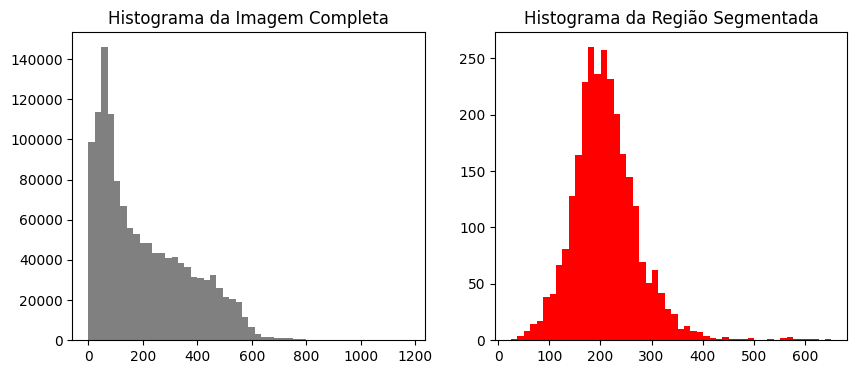

In [ ]:
def plot_histogram(image_array, label_array):
    # Extraindo valores da região segmentada
    segmented_region = image_array[label_array > 0]

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(image_array.flatten(), bins=50, color='gray')
    plt.title("Histograma da Imagem Completa")
    plt.subplot(1, 2, 2)
    plt.hist(segmented_region.flatten(), bins=50, color='red')
    plt.title("Histograma da Região Segmentada")
    plt.show()

plot_histogram(image_array, label_array)

## Avaliação Quantitativa da Segmentação
Para calcular métricas de segmentação como o Coeficiente de Dice, podemos fazer o seguinte:

In [ ]:
dice_metric = DiceMetric(include_background=False, reduction="mean")
dice_score = dice_metric(torch.tensor(label_array > 0).unsqueeze(0).unsqueeze(0),
                         torch.tensor(label_array > 0).unsqueeze(0).unsqueeze(0))
print(f"Coeficiente de Dice: {dice_score.item()}")

Coeficiente de Dice: 1.0


Um Coeficiente de Dice (também conhecido como índice de Sørensen-Dice) de 1.0 indica uma correspondência perfeita entre a segmentação prevista pelo modelo e a segmentação de referência (ou ground truth). O Coeficiente de Dice é uma métrica comum usada para avaliar o desempenho de algoritmos de segmentação de imagens, especialmente em aplicações médicas.

O resultado é um valor entre 0 e 1, onde:

1.0 significa uma sobreposição perfeita, indicando que a segmentação prevista é exatamente igual à segmentação de referência.
0 indica nenhuma sobreposição entre a segmentação prevista e a de referência.
Portanto, um Coeficiente de Dice de 1.0 é o melhor resultado possível, sugerindo que o modelo de segmentação realizou uma segmentação impecável, pelo menos para os dados em questão. Em contextos práticos, especialmente em segmentação de imagens médicas, alcançar um Dice de 1.0 em dados reais é extremamente raro e sugere uma alta precisão do modelo. No entanto, é sempre importante validar essa perfeição em um conjunto amplo e representativo de dados para garantir que não se trata de um caso específico ou de um possível overfitting.

# Comparação entre Técnicas de Segmentação

Comparar dois ou mais modelos preditivos para a tarefa de segmentação de imagens médicas é um processo fundamental para identificar a abordagem mais eficaz para um problema específico, como a segmentação de lesões de câncer de próstata em imagens de ressonância magnética (MRI). O processo geralmente envolve várias etapas, incluindo a preparação dos dados, o treinamento dos modelos, a avaliação de seu desempenho e a análise comparativa dos resultados.

## Definição dos Modelos

O MONAI (Medical Open Network for AI) é otimizado para aplicações de saúde, oferecendo ferramentas específicas para o treinamento e avaliação de modelos de aprendizado profundo em imagens médicas. Ele inclui implementações prontas de várias arquiteturas de rede neural, incluindo U-Net, V-Net, e redes baseadas em Transformer, que são adequadas para tarefas de segmentação.

Depois de carregar o arquivo JSON e extrair os dados necessários, preparamos os dados para o treinamento usando transformações do MONAI e criar DataLoader para treinamento.

In [ ]:
def prepare_data(preprocessed_data_path, overviews_path, clinical_df):
    preprocessed_data_path = Path(preprocessed_data_path)
    overviews_path = Path(overviews_path)
    overviews_path.mkdir(parents=True, exist_ok=True)

    clinical_df['patient_id'] = clinical_df['patient_id'].astype(str)
    clinical_df['study_id'] = clinical_df['study_id'].astype(str)
    ids_to_include = set(clinical_df['patient_id'] + '_' + clinical_df['study_id'])
    print(f"IDs a serem incluídos: {ids_to_include}")

    overview = {
        'pat_ids': [],
        'study_ids': [],
        'image_paths': [],
        'label_paths': [],
        'case_label': [],
        'ratio_csPCa_bg': []
    }

    for subject_id in ids_to_include:
        label_path = preprocessed_data_path / 'labelsTr' / f'{subject_id}.nii.gz'
        if not label_path.exists():
            print(f"Pulando {subject_id}, label não encontrado!")
            continue

        lbl = sitk.GetArrayFromImage(sitk.ReadImage(str(label_path)))

        overview['pat_ids'].append(subject_id.split('_')[0])
        overview['study_ids'].append(subject_id.split('_')[1])
        overview['image_paths'].append([
            str((preprocessed_data_path / 'imagesTr' / f'{subject_id}_0000.nii.gz').as_posix()),
            str((preprocessed_data_path / 'imagesTr' / f'{subject_id}_0001.nii.gz').as_posix()),
            str((preprocessed_data_path / 'imagesTr' / f'{subject_id}_0002.nii.gz').as_posix())
        ])
        overview['label_paths'].append(str(label_path.as_posix()))
        overview['case_label'].append(float(np.max(lbl)))
        overview['ratio_csPCa_bg'].append(float(np.sum(lbl) / np.size(lbl)))

    if overview['pat_ids']:
        json_path = overviews_path / f'PI-CAI_overview.json'
        with open(json_path, 'w') as fp:
            json.dump(overview, fp, indent=4)
        print(f"Visão geral salva em {json_path}")
    else:
        print("Não há dados para salvar!")

In [ ]:
prepare_data(f'{data_dir}/workdir/nnUNet_raw_data/Task2203_picai_baseline', f'{data_dir}/workdir/results/UNet/overviews', balanced_clinical_df)

IDs a serem incluídos: {'10226_1000230', '10908_1000925', '10651_1000667', '10993_1001012', '11247_1001270', '10871_1000887', '10193_1000196', '10737_1000753', '10304_1000310', '10421_1000429', '11221_1001244', '10604_1000618', '10638_1000654', '11002_1001021', '10462_1000470', '11436_1001460', '10003_1000003', '10339_1000345', '10516_1000526', '10001_1000001', '10201_1000205', '10270_1000274', '10768_1000784', '10607_1000621', '10365_1000371', '10912_1000929', '10652_1000668', '10650_1000666', '11157_1001180', '10177_1000180', '10046_1000046', '10982_1001001', '11466_1001490', '10424_1000432', '10271_1000275', '11229_1001252', '11377_1001400', '11004_1001024', '11023_1001043', '10252_1000256', '10317_1000323', '10522_1000532', '11059_1001081', '10220_1000224', '11442_1001466', '11471_1001495', '11223_1001246', '10605_1000619', '10267_1000271', '10221_1000225', '11320_1001343', '11083_1001105', '11050_1001070', '10383_1000389', '10368_1000374', '10785_1000801', '10435_1000443', '11047_

In [ ]:
json_path = f'{data_dir}/workdir/results/UNet/overviews/PI-CAI_overview.json'

with open(json_path, 'r') as file:
    data = json.load(file)

train_split = {}
valid_split = {}
test_size = 0.2

total_count = 0
train_count = 0
valid_count = 0

for key in data:
    train_split[key], valid_split[key] = train_test_split(data[key], test_size=test_size, random_state=random_state)

train_json_path = f'{data_dir}/workdir/results/UNet/overviews/PI-CAI_train-fold-5.json'
valid_json_path = f'{data_dir}/workdir/results/UNet/overviews/PI-CAI_val-fold-5.json'

with open(train_json_path, 'w') as file:
    json.dump(train_split, file, indent=4)

with open(valid_json_path, 'w') as file:
    json.dump(valid_split, file, indent=4)

print(f"Dados de treino salvos em {train_json_path}")
print(f"Dados de validação salvos em {valid_json_path}")

Dados de treino salvos em /content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/PI-CAI_train-fold-5.json
Dados de validação salvos em /content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/PI-CAI_val-fold-5.json


## UNet

A U-Net é uma arquitetura de rede neural convolucional projetada especificamente para tarefas de segmentação de imagens médicas. Sua estrutura consiste em um caminho de contração (downsampling) para capturar o contexto e um caminho simétrico de expansão (upsampling) que permite localizações precisas, tornando-a eficaz para segmentar imagens em diferentes escalas.

Esse código define uma variação avançada da rede neural U-Net usando o framework PyTorch e elementos do MONAI, um conjunto de ferramentas para redes neurais profundas em imagens médicas. Vamos explorar alguns dos componentes e funcionalidades mais notáveis deste código:

1. Estrutura da Classe UNet: A classe UNet herda de nn.Module, o que é típico para modelos em PyTorch. Ela permite a construção de um modelo modular e reutilizável.

2. Blocos Residuais: A implementação usa ResidualUnit do MONAI para adicionar blocos residuais, que ajudam a combater o problema do desaparecimento do gradiente em redes profundas. Isso é particularmente útil para a aprendizagem de características em imagens médicas, onde a preservação de detalhes ao longo de muitas camadas é crítica.

3. Conexões de Salto (Skip Connections): As skip connections são usadas para conectar diretamente partes da rede, permitindo que as ativações de camadas anteriores sejam usadas em camadas posteriores, o que ajuda a preservar características importantes ao longo de toda a rede.

4. Parâmetros de Configuração: O construtor da classe aceita vários parâmetros para personalizar a rede, incluindo o número de dimensões espaciais (spatial_dims), canais de entrada e saída, tamanhos de kernel, e mais. Isso permite ajustar a rede para diferentes tamanhos e tipos de dados de entrada.

5. Encapsulamento e Modularidade: O método _create_block é um exemplo de como a rede é construída de forma recursiva e modular. Isso facilita a compreensão e a manutenção do código.

6. Depricação: O código usa o decorador @deprecated_arg para alertar sobre o uso de argumentos obsoletos, promovendo boas práticas de atualização de código.

7. Função forward: Como qualquer modelo PyTorch, a classe UNet possui um método forward, que define como a entrada x passa através da rede.

8. Exemplos de Uso: Os comentários no código fornecem exemplos de como instanciar e usar a rede, o que é útil para desenvolvedores que podem querer implementar ou modificar o modelo para suas próprias necessidades.

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 0 --max_threads 24 --num_epochs 250 --batch_size 64 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-04-18 21:34:36.286438: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-18 21:34:36.286489: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 1 --max_threads 24 --num_epochs 250 --batch_size 64 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-04-19 21:48:55.622403: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-19 21:48:55.622458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 2 --max_threads 24 --num_epochs 250 --batch_size 64 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-04-21 02:52:14.601093: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-21 02:52:14.601133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 3 --max_threads 24 --num_epochs 250 --batch_size 64 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-04-21 23:16:59.988853: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-21 23:16:59.988900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 4 --max_threads 24 --num_epochs 250 --batch_size 64 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-04-27 21:52:13.579254: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-27 21:52:13.579305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

# Avaliação

In [ ]:
def process_model_weights(input_ckpt_path, output_ckpt_path):
    '''
    Loads model checkpoint that was stored at train-time, discards
    "optimizer_state_dict" and "epoch", and only keeps the trained
    model weights (i.e. "model_state_dict"). Reduces memory footprint
    of weights file by nearly 5x.
    '''
    checkpoint = torch.load(input_ckpt_path, map_location=torch.device('cpu'))
    torch.save({
        'model_state_dict': checkpoint['model_state_dict']}, output_ckpt_path)

In [ ]:
process_model_weights("/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F0.pt", "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/out_unet_F0.pt")
process_model_weights("/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F1.pt", "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/out_unet_F1.pt")
process_model_weights("/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F2.pt", "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/out_unet_F2.pt")
process_model_weights("/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F3.pt", "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/out_unet_F3.pt")
process_model_weights("/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F4.pt", "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/out_unet_F4.pt")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_paths = [
    '/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F0_metrics.xlsx',
    '/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F1_metrics.xlsx',
    '/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F2_metrics.xlsx',
    '/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F3_metrics.xlsx',
    '/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/unet_F4_metrics.xlsx',
]

metrics_dfs = [pd.read_excel(file) for file in file_paths]

In [ ]:
for i, df in enumerate(metrics_dfs):
    df['fold'] = i + 1

metrics_df = pd.concat(metrics_dfs, ignore_index=True)

In [ ]:
metrics_df.head()

,epoch,train_loss,valid_auroc,valid_ap,valid_ranking,fold
0,1,824144.455234,0.670000,0.000000,0.335000,1
1,2,77103.405117,0.583333,0.020635,0.301984,1
2,3,39857.962100,0.570000,0.006968,0.288484,1
3,4,29900.801992,0.586667,0.022502,0.304584,1
4,5,25431.947334,0.650000,0.011181,0.330590,1


In [ ]:
metrics_df.to_excel('/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/metrics_df.xlsx')


In [ ]:
best_epochs = metrics_df.loc[metrics_df.groupby('fold')['valid_ranking'].idxmax()]

print(best_epochs)

      epoch    train_loss  valid_auroc  valid_ap  valid_ranking  fold
195     196   6269.583571     0.673333  0.272702       0.473017     1
306      57  12368.376053     0.763333  0.505282       0.634308     2
595      95   9972.351661     0.680251  0.256822       0.468536     3
984     234   5523.559444     0.815476  0.509283       0.662379     4
1253    152   6030.229059     0.589333  0.403740       0.496537     5


In [ ]:
# Recalcular métricas resumidas por fold
summary_metrics = metrics_df.groupby('fold').agg({
    'train_loss': ['mean', 'std'],
    'valid_auroc': ['mean', 'std'],
    'valid_ap': ['mean', 'std'],
    'valid_ranking': ['mean', 'std']
}).reset_index()

# Exibir a tabela no Colab
summary_metrics.columns = ['fold', 'train_loss_mean', 'train_loss_std', 'valid_auroc_mean', 'valid_auroc_std',
                           'valid_ap_mean', 'valid_ap_std', 'valid_ranking_mean', 'valid_ranking_std']

print(summary_metrics)

   fold  train_loss_mean  train_loss_std  valid_auroc_mean  valid_auroc_std  \
0     1     11768.927673    51959.069496          0.611947         0.041264   
1     2     12068.846927    51291.662940          0.736280         0.054695   
2     3     11362.304242    43429.358996          0.641035         0.032745   
3     4     11644.590503    42734.448831          0.710107         0.072388   
4     5     11213.697146    42236.268728          0.571875         0.029732   

   valid_ap_mean  valid_ap_std  valid_ranking_mean  valid_ranking_std  
0       0.182104      0.064882            0.397025           0.036254  
1       0.392669      0.079580            0.564475           0.064817  
2       0.145905      0.049936            0.393470           0.036872  
3       0.282934      0.143482            0.496520           0.103416  
4       0.289050      0.053972            0.430462           0.037165  


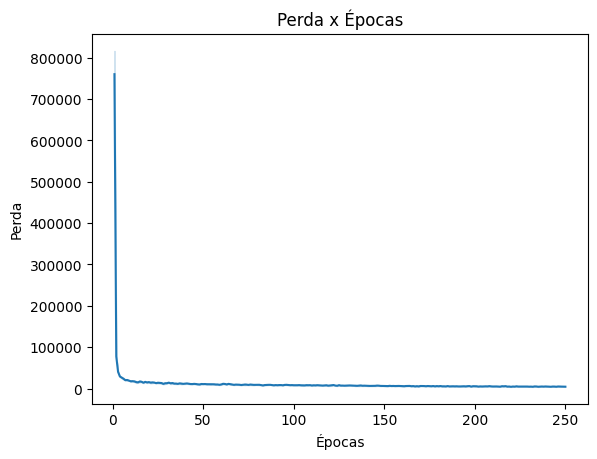

In [ ]:
sns.lineplot(data=metrics_df, x="epoch", y="train_loss")
plt.title("Perda x Épocas")
plt.xlabel("Épocas")
_ = plt.ylabel("Perda")

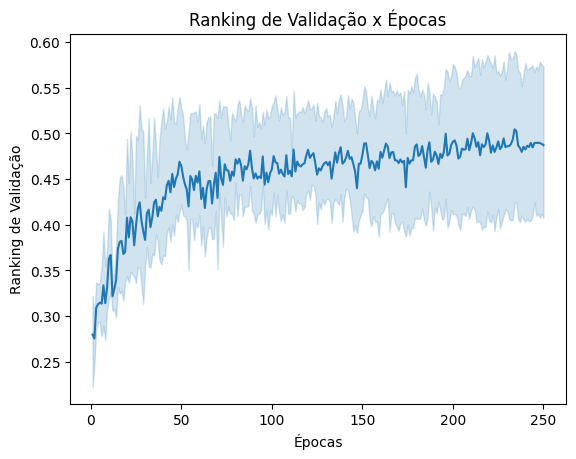

In [ ]:
sns.lineplot(data=metrics_df, x="epoch", y="valid_ranking")
plt.title("Ranking de Validação x Épocas")
plt.xlabel("Épocas")
_ = plt.ylabel("Ranking de Validação")

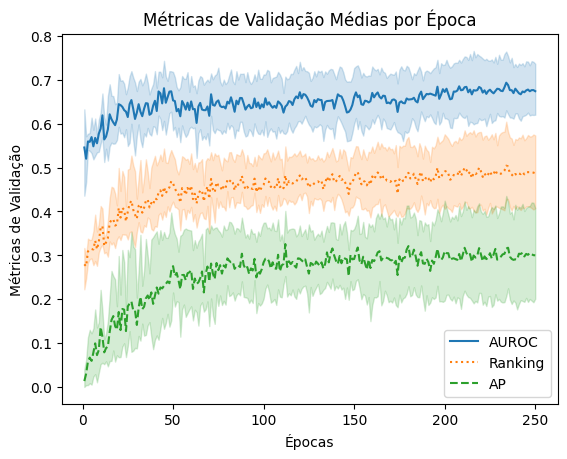

In [ ]:
sns.lineplot(data=metrics_df, x="epoch", y="valid_auroc", label="AUROC", linestyle='-')
sns.lineplot(data=metrics_df, x="epoch", y="valid_ranking", label="Ranking", linestyle=':')
sns.lineplot(data=metrics_df, x="epoch", y="valid_ap", label="AP", linestyle='--')
plt.title("Métricas de Validação Médias por Época")
plt.xlabel("Épocas")
_ = plt.ylabel("Métricas de Validação")


# Aplicando transoformações para comparações

O tamanho do lote (Batch Size) é um hiperparâmetro importante que influencia o treinamento de modelos de deep learning. Ele determina o número de amostras de treinamento usadas para calcular o gradiente de uma única atualização dos pesos da rede. Alterar o batch size pode ter impactos significativos no treinamento e no desempenho do modelo.

## Batch Size 8

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/8/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 0 --max_threads 24 --num_epochs 150 --batch_size 8 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-10 22:00:07.962905: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-10 22:00:07.962958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/8/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 1 --max_threads 24 --num_epochs 150 --batch_size 8 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-11 18:11:14.172416: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-11 18:11:14.172459: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/8/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 2 --max_threads 24 --num_epochs 150 --batch_size 8 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-11 21:34:49.283512: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-11 21:34:49.283558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/8/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 3 --max_threads 24 --num_epochs 150 --batch_size 8 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-12 06:42:00.460970: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-12 06:42:00.461026: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/8/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 4 --max_threads 24 --num_epochs 150 --batch_size 8 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-12 19:24:12.760004: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-12 19:24:12.760057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

Batch Size 16

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/16/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 0 --max_threads 24 --num_epochs 150 --batch_size 16 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-14 13:52:07.918382: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-14 13:52:07.918427: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/16/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 1 --max_threads 24 --num_epochs 150 --batch_size 16 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-15 14:36:08.017664: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-15 14:36:08.017715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/16/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 4 --max_threads 24 --num_epochs 150 --batch_size 16 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-16 04:20:03.827797: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-16 04:20:03.827862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

Batch Size 32

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/32/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 0 --max_threads 24 --num_epochs 150 --batch_size 32 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-18 22:52:27.137785: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-18 22:52:27.137829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
!python -u "/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/picai_baseline/src/picai_baseline/unet/train.py" \
  --weights_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/32/' \
  --overviews_dir='/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/overviews/' \
  --folds 3 --max_threads 24 --num_epochs 150 --batch_size 32 \
  --validate_n_epochs 1 --validate_min_epoch 0

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

2024-06-21 03:36:08.440647: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-21 03:36:08.440703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been re

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_metrics(batch_size, base_path):
    file_paths = [
        f'{base_path}/{batch_size}/unet_F0_metrics.xlsx',
        f'{base_path}/{batch_size}/unet_F1_metrics.xlsx',
        f'{base_path}/{batch_size}/unet_F2_metrics.xlsx',
        f'{base_path}/{batch_size}/unet_F3_metrics.xlsx',
        f'{base_path}/{batch_size}/unet_F4_metrics.xlsx',
    ]
    metrics_dfs = [pd.read_excel(file) for file in file_paths]
    combined_df = pd.concat(metrics_dfs, keys=[f'Fold_{i}' for i in range(5)])
    combined_df['Batch Size'] = batch_size
    return combined_df.reset_index(level=0).rename(columns={'level_0': 'Fold'})

base_path = '/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights'
batch_sizes = [8, 16, 32]

all_metrics = pd.concat([load_metrics(size, base_path) for size in batch_sizes])

# Salvar o DataFrame all_metrics como um arquivo Excel
output_path = '/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/all_metrics.xlsx'
all_metrics.to_excel(output_path, index=False)


In [ ]:
import pandas as pd

all_metrics = pd.read_excel("/content/drive/MyDrive/Documentos/Gustavo/Cursos/Inteligencia Artificial Aplicada/TCC/PICAI_Dataset/workdir/results/UNet/weights/all_metrics.xlsx")
all_metrics.head()

,Fold,epoch,train_loss,valid_auroc,valid_ap,valid_ranking,Batch Size
0,Fold_0,1,653432.933281,0.522727,0.050000,0.286364,8
1,Fold_0,2,73129.892285,0.550000,0.088095,0.319048,8
2,Fold_0,3,38713.965039,0.540909,0.075000,0.307955,8
3,Fold_0,4,29649.220908,0.559091,0.108750,0.333920,8
4,Fold_0,5,25505.292227,0.545455,0.094361,0.319908,8


In [ ]:
detailed_summary = all_metrics.groupby('Batch Size').agg({
    'train_loss': ['mean', 'std'],
    'valid_auroc': ['mean', 'std'],
    'valid_ap': ['mean', 'std'],
    'valid_ranking': ['mean', 'std']
}).reset_index()

# Flatten the MultiIndex columns
detailed_summary.columns = ['Batch Size', 'Train Loss Mean', 'Train Loss Std',
                            'AUROC Mean', 'AUROC Std', 'AP Mean', 'AP Std',
                            'Ranking Mean', 'Ranking Std']

# Exibir o resumo
print(detailed_summary)


   Batch Size  Train Loss Mean  Train Loss Std  AUROC Mean  AUROC Std  \
0           8     15313.522701    57527.104508    0.656437   0.123678   
1          16     26004.638326   119658.471272    0.703818   0.110896   
2          32     52813.746316   264437.808567    0.686526   0.088156   

    AP Mean    AP Std  Ranking Mean  Ranking Std  
0  0.306024  0.134449      0.481231     0.114929  
1  0.330314  0.136990      0.517066     0.108765  
2  0.312810  0.176046      0.499668     0.117058  


In [ ]:
grouped_df = all_metrics.groupby(['epoch', 'Batch Size'])

means = grouped_df.agg(train_loss_mean=pd.NamedAgg(column='train_loss', aggfunc='mean'),
                      valid_auroc_mean=pd.NamedAgg(column='valid_auroc', aggfunc='mean'),
                      valid_ap_mean=pd.NamedAgg(column='valid_ap', aggfunc='mean'),
                      valid_ranking_mean=pd.NamedAgg(column='valid_ranking', aggfunc='mean'))

In [ ]:
means.head()

train_loss_mean  valid_auroc_mean  valid_ap_mean  \
epoch Batch Size                                                     
1     8              7.346564e+05          0.503520       0.010000   
      16             1.582202e+06          0.492676       0.000000   
      32             3.253378e+06          0.431973       0.000000   
2     8              7.571124e+04          0.509746       0.047879   
      16             1.502009e+05          0.641109       0.067327   

                  valid_ranking_mean  
epoch Batch Size                      
1     8                     0.256760  
      16                    0.246338  
      32                    0.215987  
2     8                     0.278812  
      16                    0.354218

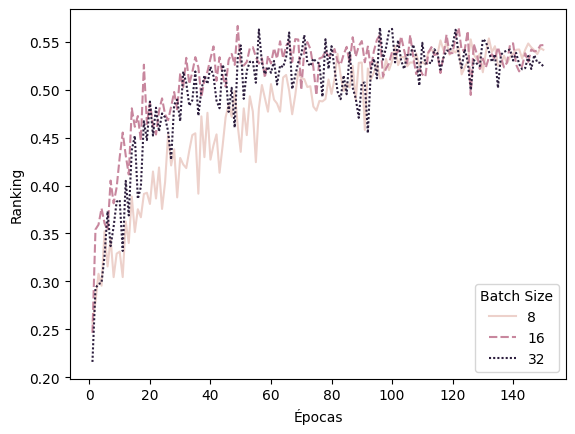

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data=means.reset_index(), x="epoch", y="valid_ranking_mean", hue="Batch Size", style="Batch Size")

plt.xlabel("Épocas")
plt.ylabel("Ranking")

plt.show()

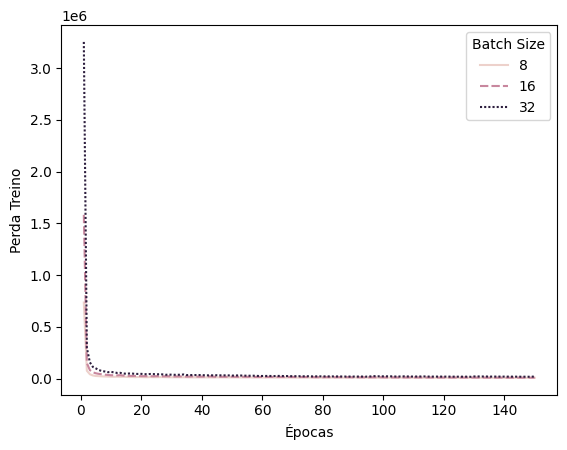

In [ ]:
sns.lineplot(data=means.reset_index(), x="epoch", y="train_loss_mean", hue="Batch Size", style="Batch Size")

plt.xlabel("Épocas")
plt.ylabel("Perda Treino")

plt.show()

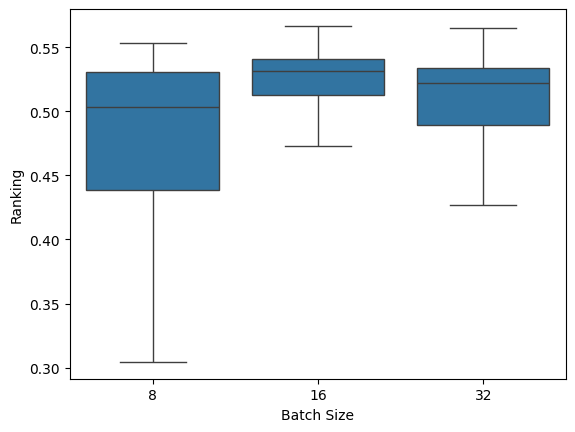

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(data=means.reset_index(), x='Batch Size', y="valid_ranking_mean", showfliers=False)
plt.ylabel("Ranking")
plt.show()
